In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.ensemble import RandomForestClassifier # Used for initial feature selection
from sklearn.metrics import classification_report, accuracy_score

# Explainability
%pip install eli5
import eli5
from eli5.sklearn import PermutationImportance
import shap

warnings.filterwarnings('ignore')
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [eli5]
Note: you may need to restart the kernel to use updated packages.


2026-02-14 16:56:47.823612: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-14 16:56:48.576125: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-14 16:56:50.993605: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# ---------------------------------------------------------
# 1. Data Loading & Preprocessing
# ---------------------------------------------------------
# Load dataset (ensure the path matches your environment)
data = pd.read_csv('heart_cleveland_upload.csv')

# Separate Target and Features
target = 'condition'
y = data[target]
X = data.drop(columns=[target])

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

print(f"Data Shape: {data.shape}")
print("Train/Test Split Complete.")

Data Shape: (297, 14)
Train/Test Split Complete.


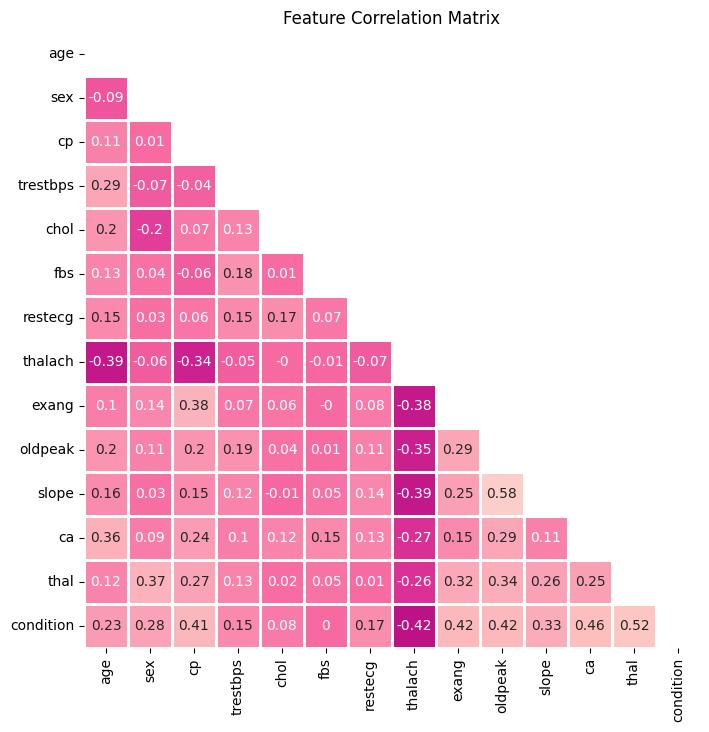

In [3]:
# ---------------------------------------------------------
# 2. Concise EDA (Correlation)
# ---------------------------------------------------------
# A shortened version of the EDA from the second notebook
plt.figure(figsize=(10, 8))
corr_mat = data.corr().round(2)
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, vmin=-1, vmax=1, center=0, 
            cmap='RdPu_r', square=True, lw=2, annot=True, cbar=False)
plt.title('Feature Correlation Matrix')
plt.show()

In [7]:


# ---------------------------------------------------------
# 3. Feature Selection (Technique from Notebook 1)
# ---------------------------------------------------------
# We use a fast Tree model to determine Permutation Importance for selection
# This fulfills the "Feature Selection" request before training the heavier GP model.
rf_selector = RandomForestClassifier(random_state=33).fit(X_train, y_train)
perm = PermutationImportance(rf_selector, random_state=33).fit(X_test, y_test)

# Display weights
print("\nFeature Importances (for Selection):")
print(eli5.format_as_text(eli5.explain_weights(perm, feature_names=X.columns.tolist())))

# Select features with weight > 0 (or a specific threshold)
# For this example, we keep all positive contributors to feed into the GP
# You can manually filter X_train based on the output above if desired.
selected_features = [feat for feat, weight in zip(X.columns, perm.feature_importances_) if weight > 0]
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]


Feature Importances (for Selection):
Explained as: feature importances

Feature importances, computed as a decrease in score when feature
values are permuted (i.e. become noise). This is also known as 
permutation importance.

If feature importances are computed on the same data as used for training, 
they don't reflect importance of features for generalization. Use a held-out
dataset if you want generalization feature importances.

0.0700 ± 0.0133  ca
0.0367 ± 0.0389  thal
0.0233 ± 0.0340  cp
0.0167 ± 0.0298  slope
0.0167 ± 0.0365  oldpeak
0.0100 ± 0.0267  sex
0.0067 ± 0.0340  chol
0.0033 ± 0.0249  age
     0 ± 0.0000  fbs
-0.0033 ± 0.0133  exang
-0.0033 ± 0.0133  trestbps
-0.0100 ± 0.0340  thalach
-0.0100 ± 0.0340  restecg


In [8]:
# ---------------------------------------------------------
# 4. Gaussian Process Classification (Model from Notebook 2)
# ---------------------------------------------------------
# Using Standard Sklearn GPC instead of the custom library for stability
kernel = 1.0 * RBF(1.0)
gpc = GaussianProcessClassifier(kernel=kernel, random_state=33, n_jobs=-1)

print(f"\nTraining Gaussian Process on {len(selected_features)} features...")
gpc.fit(X_train_sel, y_train)

# Predictions
y_pred = gpc.predict(X_test_sel)
print(f"GPC Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Training Gaussian Process on 8 features...
GPC Accuracy: 0.5833

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.78      0.59        23
           1       0.77      0.46      0.58        37

    accuracy                           0.58        60
   macro avg       0.62      0.62      0.58        60
weighted avg       0.66      0.58      0.58        60



In [9]:
# ---------------------------------------------------------
# 5. Explainability (Techniques from Notebook 1 applied to GPC)
# ---------------------------------------------------------

# A. Permutation Importance on the GPC Model
# -------------------------------------------
perm_gpc = PermutationImportance(gpc, random_state=33).fit(X_test_sel, y_test)
display(eli5.show_weights(perm_gpc, feature_names=selected_features, top=10))

# B. SHAP Values (KernelExplainer)
# -------------------------------------------
# Note: GPC is not a tree, so we use KernelExplainer. 
# We summarize X_train using K-means to speed up calculation.
print("Calculating SHAP values (this may take a moment)...")
X_train_summary = shap.kmeans(X_train_sel, 10)
explainer = shap.KernelExplainer(gpc.predict_proba, X_train_summary)

# Calculate SHAP values for the test set (using class 1 probability)
shap_values = explainer.shap_values(X_test_sel)

# SHAP Summary Plot
shap.summary_plot(shap_values[1], X_test_sel)

# SHAP Force Plot (Individual Prediction)
# Visualize the first instance in the test set
shap.initjs()
display(shap.force_plot(explainer.expected_value[1], shap_values[1][0,:], X_test_sel.iloc[0,:]))

Weight,Feature
0.0800 ± 0.0952,chol
0.0400 ± 0.1087,age
0.0300 ± 0.0249,cp
0.0000 ± 0.0365,thal
0.0000 ± 0.0211,ca
0 ± 0.0000,sex
-0.0033 ± 0.0442,oldpeak
-0.0133 ± 0.0133,slope


Calculating SHAP values (this may take a moment)...


100%|██████████| 60/60 [00:06<00:00,  9.65it/s]


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.